# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.
Note that throughout we use the numerator (Jacobian) layout, in which the derivative of a
*scalar* with respect to a vector is a **row** vector — consistent with the example
$\partial(\boldsymbol{A}\boldsymbol{x})/\partial\boldsymbol{x}=\boldsymbol{A}$ in the hint below and with Faisal et al.; if you prefer the
column-gradient convention you will obtain the equivalent transposed results, e.g.
$(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{a}$ instead of $\boldsymbol{a}^T(\boldsymbol{A}+\boldsymbol{A}^T)$.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

## Part 1
In this part we need to find the derivatives for the matrix, We assume 

$$
a =
\begin{bmatrix}
a_1 \\
a_2 \\
a_3
\end{bmatrix},
\qquad
x =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$

Then

$$
a^T x = a_1x_1 + a_2x_2 + a_3x_3
$$

Therefore,

$$
\frac{\partial(a^T x)}{\partial x}
=
\begin{bmatrix}
a_1 & a_2 & a_3
\end{bmatrix}
=
a^T
$$

## Part 2
We need to find the derivative of

$$
a^T A a
$$

Let

$$
f(a) = a^T A a
$$

Using the product rule,

$$
df = (da)^T A a + a^T A(da)
$$

Since the expression is a scalar,

$$
(da)^T A a = a^T A^T (da)
$$

Therefore,

$$
df = a^T A^T(da) + a^T A(da)
$$

$$
df = a^T(A + A^T)(da)
$$

Hence,

$$
\frac{\partial(a^T A a)}{\partial a}
=
a^T(A + A^T)
$$
## Part 3

Let

$$
f(s) = (x-As)^T(x-As)
$$

Expanding the expression gives

$$
f(s)
=
x^Tx - x^TAs - s^TA^Tx + s^TA^TAs
$$

Since $x^TAs$ is a scalar,

$$
x^TAs = s^TA^Tx
$$

so

$$
f(s)
=
x^Tx - 2x^TAs + s^TA^TAs
$$

Taking the derivative with respect to $s$,

$$
\frac{\partial f}{\partial s}
=
-2x^TA + 2s^TA^TA
$$

Therefore,

$$
\frac{\partial (x-As)^T(x-As)}{\partial s}
=
-2(x-As)^TA
$$

For the second derivative,

$$
\frac{\partial^2 f}{\partial s^2}
=
2A^TA
$$

## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [4]:
import numpy as np

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

In [12]:

# Your code for exercise 2 here

# Part 1
#First define the regression matrix.


X = np.c_[np.ones((len(x),1)),x,x**2] #First column equal 1, and let them together, since we have the quadratic polynomial , 1, x ,x^2

# The least square problem, we want to find the parameter theta. 

result = np.linalg.lstsq(X, y, rcond=None)
theta = result[0]
print(theta)

#Part 2 
from sklearn.linear_model import LinearRegression
X_sklearn = np.c_[x, x**2] 

model = LinearRegression()
model.fit(X_sklearn, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Own code:")
print(theta)

print("Scikit-learn:")
print(model.intercept_)
print(model.coef_)
#Part 3

#The best is the MSE= 0
#Compute the MSE

# Part 3

from sklearn.metrics import mean_squared_error, r2_score

y_tilde = model.predict(X_sklearn)

mse = mean_squared_error(y, y_tilde)
r2 = r2_score(y, y_tilde)

print("MSE:", mse)
print("R2:", r2)

#Test 
for noise in [0.01, 0.1, 0.5, 1.0]:

    rng = np.random.default_rng(2026)

    x = rng.random((100, 1))
    y = 2.0 + 5.0*x*x + noise*rng.standard_normal((100, 1))

    X_sklearn = np.c_[x, x**2]

    model = LinearRegression()
    model.fit(X_sklearn, y)

    y_tilde = model.predict(X_sklearn)

    mse = mean_squared_error(y, y_tilde)
    r2 = r2_score(y, y_tilde)

    print("Noise:", noise)
    print("MSE:", mse)
    print("R2:", r2)
    print()

#Conclusion
#When the noise level increases, the data points become more scattered around the true quadratic function, Therefore the MSE increases
#and the R2 score decreases meaning that the quality of the fit becomes worse.

[[ 2.2956252 ]
 [-0.48329088]
 [ 5.18566645]]
Intercept: [2.2956252]
Coefficients: [[-0.48329088  5.18566645]]
Own code:
[[ 2.2956252 ]
 [-0.48329088]
 [ 5.18566645]]
Scikit-learn:
[2.2956252]
[[-0.48329088  5.18566645]]
MSE: 1.3728156746262998
R2: 0.5596081296107469
Noise: 0.01
MSE: 0.0001372815674626294
R2: 0.9999288707828322

Noise: 0.1
MSE: 0.013728156746263003
R2: 0.9928732429893427

Noise: 0.5
MSE: 0.3432039186565751
R2: 0.8425569982752908

Noise: 1.0
MSE: 1.3728156746262998
R2: 0.5596081296107469



## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [6]:
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

Training MSE: 0.035427275084411985
Test MSE: 0.018729441285138978


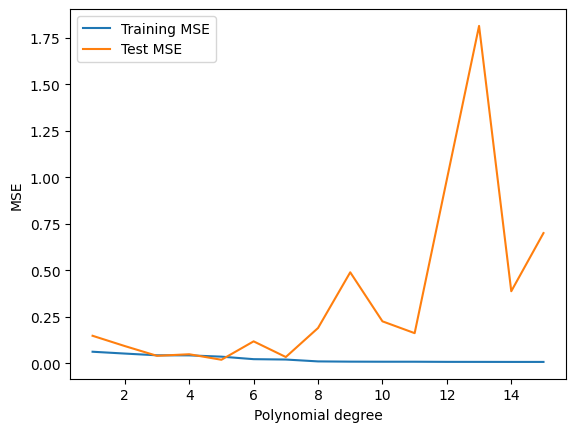

Best polynomial degree: 5
Best test MSE: 0.018729441285138978


In [15]:
#The initial data
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt 
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)
rng = np.random.default_rng(2026)

n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)

y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) \
    + rng.normal(0, 0.1, x.shape)
# Your code for exercise 3 here


x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.3, random_state=2026)
#Problem 3.1

#The fifth/order polynomial design matrices

X_train = np.vander(x_train.ravel(), 6, increasing=True) #Train
X_test = np.vander(x_test.ravel(), 6, increasing=True) #Test


#Problem 3.2
# OLS fit using training data
theta = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
#Prediction train and test, USe X_train and y_train to compute the parameter.

y_train_pred = X_train @ theta 
y_test_pred = X_test @ theta

#Compute the MSE 

def MSE(y_true,y_pred):
    return np.mean((y_true-y_pred)**2)

mse_train = MSE(y_train, y_train_pred)
mse_test = MSE(y_test, y_test_pred)

print("Training MSE:", mse_train)
print("Test MSE:", mse_test)

#Problem 3.3

train_mse = []
test_mse = []


for d in range(1,16):
    X_train = np.vander(x_train.ravel(), d+1, increasing=True)
    X_test = np.vander(x_test.ravel(), d+1, increasing=True)
    theta = np.linalg.lstsq(X_train,y_train,rcond=None)[0]

    y_train_pred = X_train @ theta
    y_test_pred = X_test @ theta 
    train_mse.append (MSE(y_train,y_train_pred))
    test_mse.append(MSE(y_test,y_test_pred))


degrees = range (1,16)

plt.plot(degrees,train_mse,label="Training MSE")
plt.plot(degrees,test_mse,label = "Test MSE") 


plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.show()
best_index = np.argmin(test_mse)
best_degree = best_index + 1
best_test_mse = test_mse[best_index]

print("Best polynomial degree:", best_degree)
print("Best test MSE:", best_test_mse)

#Conclusion

#The training MSE decreases as the polynomial degree increases.

##The best polynomial degree was 5. with a test MSE 0.018729441285138978
#For low polynomial degrees, the model is too simple and underfits the data. For high polynomial degrees,
# the model fits the training data very well but performs worse on the test data, which indicates overfitting.

#Hence, the optimal polynomial degree in this case is 5.

## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

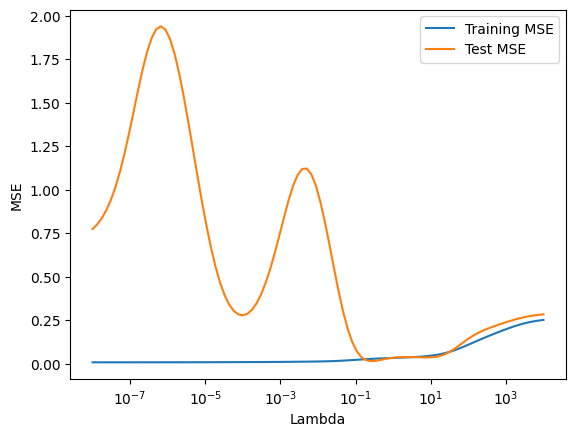

Best OLS degree: 5
Best OLS test MSE: 0.018729441285138978
Best Ridge lambda: 0.2477076355991714
Best Ridge test MSE: 0.014073212654308782
Best lambda: 0.2477076355991714
Best Ridge test MSE: 0.014073212654308782
Training MSE monotonically increasing: True


In [ ]:
# Your code for exercise 4 here

#Problem 4


d = 15 # The degree of polynomial 

#design matrix
X_train = np.vander( x_train.ravel(),d + 1,increasing=True) #x^0 = 1, so d+1

X_test = np.vander(x_test.ravel(),d + 1,increasing=True)

# Remove intercept column
Xtrain = X_train[:, 1:]
Xtest = X_test[:, 1:]


# Training statistics only
mean_X = np.mean(Xtrain, axis=0)
std_X = np.std(Xtrain, axis=0)

Xtr_scaled = (Xtrain - mean_X) / std_X
Xtest_scaled = (Xtest - mean_X) / std_X


# Center y
y_mean = np.mean(y_train)
y_train_centered = y_train.ravel() - y_mean


# Ridge using SVD
def ridge_svd(X, y, lmbda):

    U, s, Vt = np.linalg.svd(X,full_matrices=False)

    return Vt.T @ (s / (s**2 + lmbda) * (U.T @ y))


# Lambda grid
lambdas = np.logspace(-8, 4, 100)

train_mse_ridge = []
test_mse_ridge = []


for lmbda in lambdas:

    theta = ridge_svd(Xtr_scaled,y_train_centered,lmbda)

    y_train_pred = Xtr_scaled @ theta + y_mean
    y_test_pred = Xtest_scaled @ theta + y_mean

    train_mse_ridge.append(MSE(y_train.ravel(), y_train_pred))

    test_mse_ridge.append(MSE(y_test.ravel(), y_test_pred))


plt.plot(lambdas,train_mse_ridge,label="Training MSE")

plt.plot(lambdas,test_mse_ridge,label="Test MSE")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.legend()
plt.show()


best_index = np.argmin(test_mse_ridge)
best_lambda = lambdas[best_index]
best_ridge_mse = test_mse_ridge[best_index]
best_degree_index = np.argmin(test_mse)
best_degree = best_degree_index + 1
best_ols_mse = test_mse[best_degree_index]
print("Best OLS degree:", best_degree)
print("Best OLS test MSE:", best_ols_mse)
print("Best Ridge lambda:", best_lambda)
print("Best Ridge test MSE:", best_ridge_mse)
print("Training MSE monotonically increasing:", np.all(np.diff(train_mse_ridge) >= 0))

#Conclusion

#The training MSE increases as lambda increases. The test MSE first decreases and then increases again, showing the expected U-shaped behaviour.
# This means that small Ridge penaltly can reduce overfitting, while a very large lambda makes the model too restricted.


#Part 2.

#The best polynomial degree was 5. with a test MSE 0.018729441285138978

#For Ridge regression the best lambda was 0.2477076355991714

#a test MSE was 0.014073212654308782

#The Ridge model gives a lower test MSE in this case.


#part 3

#The monotonicity check returns true.